## CONFIG

In [2]:
import sys
import subprocess
import pkgutil
from pathlib import Path
import copy
import os
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

def ensure_package(pkg_name, pip_name=None):
    if pkgutil.find_loader(pkg_name) is None:
        name = pip_name or pkg_name
        print(f"Installing {name} ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", name])
    else:
        print(f"{pkg_name} already installed.")

ensure_package("torch_geometric", "torch-geometric")

torch_geometric already installed.


In [71]:
use_day_embedding = True
day_emb_dim = 3

CONFIG = {
    "BASE_DIR": Path('.'),

    "PATH_ELEC_NETWORK": Path('./Elec Network Data.xlsx'),
    "PATH_GAS_NETWORK": Path('./Gas Network Data.xlsx'),
    "PATH_WIND": Path('./input/Wind Data.xlsx'),
    "PATH_LOAD": Path('./input/Elec Load Data.xlsx'),
    "PATH_CONS_DISTRIB": Path('./input/Gas Cons Distrib.xlsx'),
    "PATH_CONS_EXPORT": Path('./input/Gas Cons Export.xlsx'),
    "PATH_CONS_IND": Path('./input/Gas Cons Ind.xlsx'),
    "PATH_DECISION": Path('./output/Decision_variablesRU.xlsx'),

    "MONTHS": [f"{m:02d}" for m in range(1, 13)],

    "NUM_ELEC_NODES": 45,
    "NUM_GAS_NODES": 28,
    "GENERATOR_BUS_IDX": [6, 12, 14, 15, 18, 26, 27, 28, 32, 35, 37, 39, 41, 43, 44],
    "NUM_GENERATORS": 24,
    "WELL_IDX": [0, 4, 16, 17],

    "HIST_HOURS": 72,
    "HORIZON_HOURS": 24,
    "STRIDE_HOURS": 24,

    "TRAIN_END": "2024-10-01 00:00:00",
    "VAL_END": "2024-11-01 00:00:00",

    # Elec dynamic features
    "USE_LOAD_HISTORY": True,
    "USE_WIND_OFFSHORE_HISTORY": False,
    "USE_WIND_ONSHORE_HISTORY": False,
    "USE_P_HISTORY": False,

    # Elec node static features
    "USE_NODE_STATIC_IS_GENERATOR": True,
    "USE_NODE_STATIC_GENERATOR_COUNT": False,
    "USE_NODE_STATIC_PMAX_TOTAL": False,
    "USE_NODE_STATIC_LOAD_SHARE": False,
    "USE_NODE_STATIC_PV_SHARE": False,
    "USE_NODE_STATIC_ONSHORE_SHARE": False,
    "USE_NODE_STATIC_IS_OFFSHORE": False,
    "USE_NODE_STATIC_IS_IMPORT": False,
    "USE_NODE_STATIC_IMPORT_PMAX": False,
    "USE_NODE_STATIC_VOLTAGE_KV": False,
    "USE_NODE_STATIC_IS_TRANSFER": False,
    "USE_NODE_STATIC_DEGREE": False,

    # Gas dynamic features
    "USE_PR_HISTORY": False,
    "USE_RES_DEMAND_HISTORY": True,
    "USE_IND_DEMAND_HISTORY": True,
    "USE_EXP_DEMAND_HISTORY": False,
    "USE_GFPP_GAS_LOAD_HISTORY": True,
    "USE_G_HISTORY": False,
    "USE_RAW_P_HISTORY_ON_GAS_NODES": False,

    # Gas node static features
    "USE_NODE_STATIC_IS_WELL": True,
    "USE_NODE_STATIC_SHARES": False,
    "USE_NODE_STATIC_PRESSURE_BOUNDS": False,
    "USE_NODE_STATIC_DEGREE": False,
    "USE_NODE_STATIC_IS_GFPP_LOAD_NODE": False,
    "USE_NODE_STATIC_GFPP_COUNT": False,

    "ELEC_EDGE_STATIC_COLUMNS": ["X_pu", "b_pu", "Pmax_MW", "Length_km", "Inom_A", "UB_kV"],
    "GAS_EDGE_STATIC_COLUMNS": [
        "Natural gas flow constant [MNm3/(bar*h)2]",
        "Compressor factor",
        "High Linepack",
        "Initial linepack [MNm3]",
        "Linepack constant [MNm3/bar]",
        "Estimated lenght [km]",
    ],
    "USE_BIDIRECTIONAL_EDGES": True,

    # GFPP conversion
    "GFPP_P_TO_MW_MULTIPLIER": 100.0,
    "GFPP_GAS_ENERGY_CONTENT_MWH_PER_MNM3": 11000.0,
    "GFPP_DEFAULT_EFFICIENCY": 0.55,
    "GFPP_EFFICIENCY_BY_GENERATOR": {},

    # Model
    "MODEL_TYPE": "gine",
    "ELEC_HIDDEN_DIM": 8,
    "GAS_HIDDEN_DIM": 8,
    "ELEC_ENCODER_HIDDEN_DIMS": [64, 32],
    "GAS_ENCODER_HIDDEN_DIMS": [8, 4],
    "ELEC_DECODER_HIDDEN_DIMS": [32, 64],
    "GAS_DECODER_HIDDEN_DIMS": [4, 8],
    "NUM_MP_LAYERS_ELEC": 2,
    "NUM_MP_LAYERS_GAS": 2,
    "DROPOUT": 0.1,
    "USE_BATCHNORM": True,
    "ELEC_RESIDUAL": True,
    "GAS_RESIDUAL": True,
    "LAMBDA_CROSS_ELEC": 0.2,
    "LAMBDA_CROSS_GAS": 0.1,

    # Optimization
    "SEED": 42,
    "DEVICE": "cpu",
    "EPOCHS": 300,
    "BATCH_SIZE": 24,
    "LR": 1e-3,
    "WEIGHT_DECAY": 5e-4,
    "GRAD_CLIP_NORM": 2.0,
    "EARLY_STOPPING_PATIENCE": 30,
    "EARLY_STOPPING_MIN_DELTA": 1e-4,
    "SCHEDULER_FACTOR": 0.8, #0.4
    "SCHEDULER_PATIENCE": 6,
    "SCHEDULER_MIN_LR": 1e-6,

    # Loss weights
    "LAMBDA_ELEC_LOSS": 1.0,
    "LAMBDA_GAS_LOSS": 1.0,
}

PATHS = {
    "elec_network": CONFIG["BASE_DIR"] / CONFIG["PATH_ELEC_NETWORK"],
    "gas_network": CONFIG["BASE_DIR"] / CONFIG["PATH_GAS_NETWORK"],
    "wind": CONFIG["BASE_DIR"] / CONFIG["PATH_WIND"],
    "load": CONFIG["BASE_DIR"] / CONFIG["PATH_LOAD"],
    "cons_distrib": CONFIG["BASE_DIR"] / CONFIG["PATH_CONS_DISTRIB"],
    "cons_export": CONFIG["BASE_DIR"] / CONFIG["PATH_CONS_EXPORT"],
    "cons_ind": CONFIG["BASE_DIR"] / CONFIG["PATH_CONS_IND"],
    "decision": CONFIG["BASE_DIR"] / CONFIG["PATH_DECISION"],
}

HIST = CONFIG["HIST_HOURS"]
HOR = CONFIG["HORIZON_HOURS"]
STRIDE = CONFIG["STRIDE_HOURS"]
N_ELEC_NODES = CONFIG["NUM_ELEC_NODES"]
N_GAS_NODES = CONFIG["NUM_GAS_NODES"]
N_GEN_BUS = len(CONFIG["GENERATOR_BUS_IDX"])
N_WELLS = len(CONFIG["WELL_IDX"])


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def pretty_shape(name, x):
    print(f"{name}: shape={getattr(x, 'shape', None)}")


def drop_unnamed_first_col(df):
    if len(df.columns) > 0 and str(df.columns[0]).startswith("Unnamed"):
        return df.drop(columns=[df.columns[0]])
    return df


def row_normalize(mat, eps=1e-12):
    mat = np.asarray(mat, dtype=np.float32)
    row_sum = mat.sum(axis=1, keepdims=True)
    row_sum = np.maximum(row_sum, eps)
    return mat / row_sum


set_seed(CONFIG["SEED"])
DEVICE = torch.device("cuda" if (CONFIG["DEVICE"] == "cuda" and torch.cuda.is_available()) else "cpu")
print("DEVICE =", DEVICE)

for k, v in PATHS.items():
    print(f"{k}: {v.resolve()} | exists={v.exists()}")


DEVICE = cpu
elec_network: C:\Users\yoans\TFE - GAZ\Elec Network Data.xlsx | exists=True
gas_network: C:\Users\yoans\TFE - GAZ\Gas Network Data.xlsx | exists=True
wind: C:\Users\yoans\TFE - GAZ\input\Wind Data.xlsx | exists=True
load: C:\Users\yoans\TFE - GAZ\input\Elec Load Data.xlsx | exists=True
cons_distrib: C:\Users\yoans\TFE - GAZ\input\Gas Cons Distrib.xlsx | exists=True
cons_export: C:\Users\yoans\TFE - GAZ\input\Gas Cons Export.xlsx | exists=True
cons_ind: C:\Users\yoans\TFE - GAZ\input\Gas Cons Ind.xlsx | exists=True
decision: C:\Users\yoans\TFE - GAZ\output\Decision_variablesRU.xlsx | exists=True


## READERS

In [4]:
def read_decision_p(months, decision_path):
    all_arrays = []
    for m in months:
        df = pd.read_excel(decision_path, sheet_name=f"p-{m}-2024", header=0, index_col=0)
        all_arrays.append(df.to_numpy(dtype=float))
    p_full = np.concatenate(all_arrays, axis=0)
    ts_p = pd.date_range("2024-01-01", periods=len(p_full), freq="h")
    return p_full, ts_p


def read_elec_load(months, load_path):
    dfs = []
    for m in months:
        df = pd.read_excel(load_path, sheet_name=f"{m}-2024", header=0, usecols=[0, 1])
        df.columns = ["datetime", "load_MW"]
        df["datetime"] = pd.to_datetime(df["datetime"])
        dfs.append(df[["datetime", "load_MW"]])
    df_all = pd.concat(dfs, ignore_index=True).sort_values("datetime").reset_index(drop=True)
    return df_all["load_MW"].to_numpy(dtype=float), pd.DatetimeIndex(df_all["datetime"])


def read_wind(months, wind_path):
    dfs = []
    for m in months:
        df = pd.read_excel(wind_path, sheet_name=f"{m}-2024", header=0, usecols=[0, 1])
        df.columns = ["datetime", "wind_MW"]
        df["datetime"] = pd.to_datetime(df["datetime"])
        dfs.append(df[["datetime", "wind_MW"]])
    df_all = pd.concat(dfs, ignore_index=True).sort_values("datetime").reset_index(drop=True)
    return df_all["wind_MW"].to_numpy(dtype=float), pd.DatetimeIndex(df_all["datetime"])


def read_simple_monthly_series(path, months, value_col):
    parts = []
    for m in months:
        df = pd.read_excel(path, sheet_name=f"{m}-2024")
        df = df[["Date Time", value_col]].copy()
        df["Date Time"] = pd.to_datetime(df["Date Time"])
        df = df.rename(columns={value_col: "value"})
        parts.append(df)
    return pd.concat(parts, ignore_index=True).sort_values("Date Time").reset_index(drop=True)


def read_decision_tensor(prefix, months, decision_path):
    all_values, all_times = [], []
    for m in months:
        df = pd.read_excel(decision_path, sheet_name=f"{prefix}-{m}-2024")
        df = drop_unnamed_first_col(df)
        arr = df.to_numpy(dtype=float)
        idx = pd.date_range(start=pd.Timestamp(f"2024-{m}-01"), periods=len(df), freq="h")
        all_values.append(arr)
        all_times.append(idx)
    values = np.vstack(all_values)
    times = pd.DatetimeIndex(np.concatenate([x.to_numpy() for x in all_times]))
    return values, times


## ELECTRIC NETWORK and FEATURES

In [5]:
buses_df = pd.read_excel(PATHS["elec_network"], sheet_name="Buses")
lines_df = pd.read_excel(PATHS["elec_network"], sheet_name="LinesMerged")
gen_df = pd.read_excel(PATHS["elec_network"], sheet_name="Gen")
genmap_df = pd.read_excel(PATHS["elec_network"], sheet_name="GenMap", header=0)
windmap_df = pd.read_excel(PATHS["elec_network"], sheet_name="WindMap", header=0)
impmap_df = pd.read_excel(PATHS["elec_network"], sheet_name="ImpMap", header=0)
imp_df = pd.read_excel(PATHS["elec_network"], sheet_name="Imp")
renew_df = pd.read_excel(PATHS["elec_network"], sheet_name="Renew")

genmap = genmap_df.to_numpy(dtype=float)
generator_to_bus = {}
for gen_idx in range(CONFIG["NUM_GENERATORS"]):
    connected = np.where(genmap[:, gen_idx] > 0.5)[0]
    assert len(connected) == 1
    generator_to_bus[gen_idx] = int(connected[0])

pmax_per_bus = np.zeros(N_ELEC_NODES, dtype=float)
gen_count_per_bus = np.zeros(N_ELEC_NODES, dtype=int)
for gen_idx, bus_idx in generator_to_bus.items():
    pmax_val = gen_df.iloc[gen_idx]["Pmax_MW"]
    if isinstance(pmax_val, str):
        pmax_val = eval(pmax_val.replace("=", ""))
    pmax_per_bus[bus_idx] += float(pmax_val)
    gen_count_per_bus[bus_idx] += 1

transfos = buses_df["Transfos"].to_numpy(dtype=float)
load_share = transfos / transfos.sum()
windmap = windmap_df.to_numpy(dtype=float).flatten()
impmap = impmap_df.to_numpy(dtype=float)
is_import_bus = (impmap.sum(axis=1) > 0).astype(float)
import_pmax_mw = np.zeros(N_ELEC_NODES, dtype=float)
for i in range(N_ELEC_NODES):
    for j in range(impmap.shape[1]):
        if impmap[i, j] > 0.5:
            import_pmax_mw[i] += float(imp_df.iloc[j]["Pmax_MW"])

PV_SHARES_RAW = {
    1: 3.455/2, 2: 2.192/4, 4: 16.02/2, 5: 7.093/11, 7: 15.46/3, 8: 7.093/11, 10: 3.455/2,
    13: 17.37/4, 14: 17.37/4, 16: 7.625/2, 17: 7.093/11, 19: 16.02/2, 20: 7.093/11, 21: 17.26/4,
    22: 7.093/11, 23: 7.093/11, 25: 2.192/4, 26: 17.26/4, 27: 17.26/4, 28: 15.46/3, 29: 17.37/4,
    31: 7.093/11, 32: 7.093/11, 33: 17.37/4, 34: 7.093/11, 35: 2.192/4, 36: 7.093/11, 38: 7.625/2,
    40: 7.093/11, 42: 15.46/3, 43: 2.192/4, 44: 17.26/4, 45: 13.52,
}
ONSHORE_SHARES_RAW = {
    1: 11.599/2, 2: 3.459/4, 4: 8.741/2, 5: 9.825/11, 7: 5.15/3, 8: 9.825/11, 10: 11.599/2,
    13: 18.252/4, 14: 18.252/4, 16: 17.785/2, 17: 9.825/11, 19: 8.741/2, 20: 9.825/11, 21: 14.835/4,
    22: 9.825/11, 23: 9.825/11, 25: 3.459/4, 26: 14.835/4, 27: 14.835/4, 28: 5.15/3, 29: 18.252/4,
    31: 9.825/11, 32: 9.825/11, 33: 18.252/4, 34: 9.825/11, 35: 3.459/4, 36: 9.825/11, 38: 17.785/2,
    40: 9.825/11, 42: 5.15/3, 43: 3.459/4, 44: 14.835/4, 45: 10.35,
}
pv_share = np.array([PV_SHARES_RAW.get(i + 1, 0.0) for i in range(N_ELEC_NODES)], dtype=float)
onshore_share = np.array([ONSHORE_SHARES_RAW.get(i + 1, 0.0) for i in range(N_ELEC_NODES)], dtype=float)
pv_share_norm = pv_share / (pv_share.sum() + 1e-12)
onshore_share_norm = onshore_share / (onshore_share.sum() + 1e-12)

p_full, ts_p = read_decision_p(CONFIG["MONTHS"], PATHS["decision"])
load_total, ts_load = read_elec_load(CONFIG["MONTHS"], PATHS["load"])
wind_total, ts_wind = read_wind(CONFIG["MONTHS"], PATHS["wind"])
assert len(ts_p) == len(ts_load) == len(ts_wind)
T = len(ts_p)

p_bus_full = np.zeros((T, N_ELEC_NODES), dtype=float)
for gen_idx, bus_idx in generator_to_bus.items():
    p_bus_full[:, bus_idx] += p_full[:, gen_idx]
p_bus_generator = p_bus_full[:, CONFIG["GENERATOR_BUS_IDX"]]
load_nodal = load_total[:, None] * load_share[None, :]
wind_offshore_nodal = np.zeros((T, N_ELEC_NODES), dtype=float)
wind_offshore_nodal[:, 38] = wind_total
wind_onshore_nodal = wind_total[:, None] * onshore_share_norm[None, :]
p_history_nodal = p_bus_full.copy()

elec_dyn_feature_dict = {}
if CONFIG["USE_LOAD_HISTORY"]:
    elec_dyn_feature_dict["load_nodal"] = load_nodal
if CONFIG["USE_WIND_OFFSHORE_HISTORY"]:
    elec_dyn_feature_dict["wind_offshore"] = wind_offshore_nodal
if CONFIG["USE_WIND_ONSHORE_HISTORY"]:
    elec_dyn_feature_dict["wind_onshore"] = wind_onshore_nodal
if CONFIG["USE_P_HISTORY"]:
    elec_dyn_feature_dict["p_history"] = p_history_nodal

elec_dyn_tensor = np.stack([elec_dyn_feature_dict[k] for k in elec_dyn_feature_dict], axis=-1)

# static elec
degrees_elec = np.zeros(N_ELEC_NODES, dtype=float)
for _, row in lines_df.iterrows():
    u = int(row["FromNode"]) - 1
    v = int(row["ToNode"]) - 1
    degrees_elec[u] += 1
    degrees_elec[v] += 1
is_transfer = (buses_df["Type"] == "Transfer").to_numpy(dtype=float)
voltage_kv = buses_df["UB_kV"].to_numpy(dtype=float)

node_static_parts_elec = []
_ns_elec = [
    ("USE_NODE_STATIC_IS_GENERATOR", lambda: (gen_count_per_bus > 0).astype(float)[:, None]),
    ("USE_NODE_STATIC_GENERATOR_COUNT", lambda: gen_count_per_bus[:, None].astype(float)),
    ("USE_NODE_STATIC_PMAX_TOTAL", lambda: pmax_per_bus[:, None]),
    ("USE_NODE_STATIC_LOAD_SHARE", lambda: load_share[:, None]),
    ("USE_NODE_STATIC_PV_SHARE", lambda: pv_share_norm[:, None]),
    ("USE_NODE_STATIC_ONSHORE_SHARE", lambda: onshore_share_norm[:, None]),
    ("USE_NODE_STATIC_IS_OFFSHORE", lambda: windmap[:, None]),
    ("USE_NODE_STATIC_IS_IMPORT", lambda: is_import_bus[:, None]),
    ("USE_NODE_STATIC_IMPORT_PMAX", lambda: import_pmax_mw[:, None]),
    ("USE_NODE_STATIC_VOLTAGE_KV", lambda: voltage_kv[:, None]),
    ("USE_NODE_STATIC_IS_TRANSFER", lambda: is_transfer[:, None]),
    ("USE_NODE_STATIC_DEGREE", lambda: degrees_elec[:, None]),
]
for key, builder in _ns_elec:
    if CONFIG.get(key, False):
        node_static_parts_elec.append(builder())
node_static_elec = np.concatenate(node_static_parts_elec, axis=1) if node_static_parts_elec else np.zeros((N_ELEC_NODES, 0), dtype=float)

edge_static_base_elec = lines_df[CONFIG["ELEC_EDGE_STATIC_COLUMNS"]].apply(pd.to_numeric, errors="coerce").fillna(0.0).to_numpy(dtype=float)
edge_pairs_elec, edge_attrs_elec = [], []
for i, row in lines_df.iterrows():
    u = int(row["FromNode"]) - 1
    v = int(row["ToNode"]) - 1
    ea = edge_static_base_elec[i]
    edge_pairs_elec.append((u, v))
    edge_attrs_elec.append(ea)
    if CONFIG["USE_BIDIRECTIONAL_EDGES"]:
        edge_pairs_elec.append((v, u))
        edge_attrs_elec.append(ea.copy())
edge_index_elec = torch.tensor(np.array(edge_pairs_elec, dtype=np.int64).T, dtype=torch.long)
edge_attr_raw_elec = np.array(edge_attrs_elec, dtype=float)


In [6]:
print("=== Share checks ===")
print(f"sum(load_share)         = {load_share.sum():.12f}")
print(f"sum(pv_share_norm)      = {pv_share_norm.sum():.12f}")
print(f"sum(onshore_share_norm) = {onshore_share_norm.sum():.12f}")

print(f"min(load_share)         = {load_share.min():.12f}")
print(f"min(pv_share_norm)      = {pv_share_norm.min():.12f}")
print(f"min(onshore_share_norm) = {onshore_share_norm.min():.12f}")

assert np.all(load_share >= -1e-12), "Negative values in load_share"
assert np.all(pv_share_norm >= -1e-12), "Negative values in pv_share_norm"
assert np.all(onshore_share_norm >= -1e-12), "Negative values in onshore_share_norm"

assert np.isclose(load_share.sum(), 1.0, atol=1e-8), "load_share does not sum to 1"
assert np.isclose(pv_share_norm.sum(), 1.0, atol=1e-8), "pv_share_norm does not sum to 1"
assert np.isclose(onshore_share_norm.sum(), 1.0, atol=1e-8), "onshore_share_norm does not sum to 1"

print("Basic checks passed.")

=== Share checks ===
sum(load_share)         = 1.000000000000
sum(pv_share_norm)      = 1.000000000000
sum(onshore_share_norm) = 1.000000000000
min(load_share)         = 0.000000000000
min(pv_share_norm)      = 0.000000000000
min(onshore_share_norm) = 0.000000000000
Basic checks passed.


## GAS NETWORK and FEATURES

In [7]:
nodes_df = pd.read_excel(PATHS["gas_network"], sheet_name="Nodes")
pipes_df = pd.read_excel(PATHS["gas_network"], sheet_name="Pipelines")
well_df = pd.read_excel(PATHS["gas_network"], sheet_name="Well")
gfpp_map_df = pd.read_excel(PATHS["gas_network"], sheet_name="GFPPMap", header=0)
well_idx = np.array(CONFIG["WELL_IDX"], dtype=int)

cons_distrib_df = read_simple_monthly_series(PATHS["cons_distrib"], CONFIG["MONTHS"], "Physical Flow (MNm3)")
cons_ind_df = read_simple_monthly_series(PATHS["cons_ind"], CONFIG["MONTHS"], "Physical Flow (MNm3)")
cons_export_df = read_simple_monthly_series(PATHS["cons_export"], CONFIG["MONTHS"], "Physical Flow (MNm3)")

g_full, ts_g = read_decision_tensor("g", CONFIG["MONTHS"], PATHS["decision"])
pr_full, ts_pr = read_decision_tensor("pr", CONFIG["MONTHS"], PATHS["decision"])
q_full, ts_q = read_decision_tensor("q", CONFIG["MONTHS"], PATHS["decision"])
p_full_gas, ts_p_gas = read_decision_tensor("p", CONFIG["MONTHS"], PATHS["decision"])

assert len(ts_g) == len(ts_p)
assert (pd.to_datetime(ts_g) == pd.to_datetime(ts_p)).all(), "Les timelines elec/gas doivent être identiques."

gfpp_map = gfpp_map_df.to_numpy(dtype=float)
gen_cols = list(gfpp_map_df.columns)
num_generators = len(gen_cols)
generator_to_gas_node = {}
for g_idx in range(num_generators):
    connected_rows = np.where(gfpp_map[:, g_idx] > 0.5)[0]
    if len(connected_rows) == 1:
        generator_to_gas_node[g_idx] = int(connected_rows[0])

connected_generator_idx = sorted(generator_to_gas_node.keys())
connected_gas_nodes = sorted(set(generator_to_gas_node.values()))

gfpp_count_per_node = np.zeros(N_GAS_NODES, dtype=int)
for g_idx, node_idx in generator_to_gas_node.items():
    gfpp_count_per_node[node_idx] += 1
gfpp_is_load_node = (gfpp_count_per_node > 0).astype(float)

eff_by_gen = np.full(num_generators, CONFIG["GFPP_DEFAULT_EFFICIENCY"], dtype=float)
for g_idx, eff_val in CONFIG["GFPP_EFFICIENCY_BY_GENERATOR"].items():
    eff_by_gen[g_idx] = float(eff_val)

base_multiplier = float(CONFIG["GFPP_P_TO_MW_MULTIPLIER"])
gas_energy_content = float(CONFIG["GFPP_GAS_ENERGY_CONTENT_MWH_PER_MNM3"])
p_full_mw = p_full_gas * base_multiplier

gfpp_gas_consumption_per_gen = np.zeros_like(p_full_mw, dtype=float)
for g_idx in connected_generator_idx:
    gfpp_gas_consumption_per_gen[:, g_idx] = p_full_mw[:, g_idx] / (gas_energy_content * eff_by_gen[g_idx])

gfpp_gas_nodal = np.zeros((len(ts_g), N_GAS_NODES), dtype=float)
for g_idx in connected_generator_idx:
    node_idx = generator_to_gas_node[g_idx]
    gfpp_gas_nodal[:, node_idx] += gfpp_gas_consumption_per_gen[:, g_idx]

res_share = nodes_df["Res_Load_share_%"].to_numpy(dtype=float)
ind_share = nodes_df["Ind_Load_share_%"].to_numpy(dtype=float)
exp_share = nodes_df["Exp_Load_share_%"].to_numpy(dtype=float)
res_total = cons_distrib_df["value"].to_numpy(dtype=float)
ind_total = cons_ind_df["value"].to_numpy(dtype=float)
exp_total = cons_export_df["value"].to_numpy(dtype=float)
res_nodal = res_total[:, None] * res_share[None, :]
ind_nodal = ind_total[:, None] * ind_share[None, :]
exp_nodal = exp_total[:, None] * exp_share[None, :]

g_nodal = np.zeros((len(ts_g), N_GAS_NODES), dtype=float)
g_nodal[:, well_idx] = g_full
p_nodal = np.zeros((len(ts_g), N_GAS_NODES), dtype=float)
for g_idx in connected_generator_idx:
    p_nodal[:, generator_to_gas_node[g_idx]] += p_full_gas[:, g_idx]

gas_dyn_feature_dict = {}
if CONFIG["USE_PR_HISTORY"]:
    gas_dyn_feature_dict["pr"] = pr_full
if CONFIG["USE_RES_DEMAND_HISTORY"]:
    gas_dyn_feature_dict["res_demand"] = res_nodal
if CONFIG["USE_IND_DEMAND_HISTORY"]:
    gas_dyn_feature_dict["ind_demand"] = ind_nodal
if CONFIG["USE_EXP_DEMAND_HISTORY"]:
    gas_dyn_feature_dict["exp_demand"] = exp_nodal
if CONFIG["USE_GFPP_GAS_LOAD_HISTORY"]:
    gas_dyn_feature_dict["gfpp_gas_load"] = gfpp_gas_nodal
if CONFIG["USE_G_HISTORY"]:
    gas_dyn_feature_dict["g_history"] = g_nodal
if CONFIG["USE_RAW_P_HISTORY_ON_GAS_NODES"]:
    gas_dyn_feature_dict["p_history_projected_to_gas_nodes"] = p_nodal

gas_dyn_tensor = np.stack([gas_dyn_feature_dict[k] for k in gas_dyn_feature_dict], axis=-1)

# static gas
degrees_gas = np.zeros(N_GAS_NODES, dtype=float)
for _, row in pipes_df.iterrows():
    u = int(row["From node"]) - 1
    v = int(row["To node"]) - 1
    degrees_gas[u] += 1
    degrees_gas[v] += 1

node_static_parts_gas = []
if CONFIG["USE_NODE_STATIC_IS_WELL"]:
    is_well = np.zeros(N_GAS_NODES, dtype=float)
    is_well[well_idx] = 1.0
    node_static_parts_gas.append(is_well[:, None])
if CONFIG["USE_NODE_STATIC_SHARES"]:
    node_static_parts_gas.extend([res_share[:, None], ind_share[:, None], exp_share[:, None]])
if CONFIG["USE_NODE_STATIC_PRESSURE_BOUNDS"]:
    pr_min = nodes_df["Pr_min [bar]"].to_numpy(dtype=float)
    pr_max = nodes_df["Pr_max [bar]"].to_numpy(dtype=float)
    node_static_parts_gas.extend([pr_min[:, None], pr_max[:, None]])
if CONFIG["USE_NODE_STATIC_DEGREE"]:
    node_static_parts_gas.append(degrees_gas[:, None])
if CONFIG["USE_NODE_STATIC_IS_GFPP_LOAD_NODE"]:
    node_static_parts_gas.append(gfpp_is_load_node[:, None])
if CONFIG["USE_NODE_STATIC_GFPP_COUNT"]:
    node_static_parts_gas.append(gfpp_count_per_node[:, None].astype(float))
node_static_gas = np.concatenate(node_static_parts_gas, axis=1) if node_static_parts_gas else np.zeros((N_GAS_NODES, 0), dtype=float)

edge_static_base_gas = pipes_df[CONFIG["GAS_EDGE_STATIC_COLUMNS"]].apply(pd.to_numeric, errors="coerce").fillna(0.0).to_numpy(dtype=float)
edge_pairs_gas, edge_attrs_gas = [], []
for i, row in pipes_df.iterrows():
    u = int(row["From node"]) - 1
    v = int(row["To node"]) - 1
    ea = edge_static_base_gas[i]
    edge_pairs_gas.append((u, v))
    edge_attrs_gas.append(ea)
    if CONFIG["USE_BIDIRECTIONAL_EDGES"]:
        edge_pairs_gas.append((v, u))
        edge_attrs_gas.append(ea.copy())
edge_index_gas = torch.tensor(np.array(edge_pairs_gas, dtype=np.int64).T, dtype=torch.long)
edge_attr_raw_gas = np.array(edge_attrs_gas, dtype=float)


## COMMON TIME and SCALING

In [8]:
from sklearn.preprocessing import StandardScaler

ts_common = pd.to_datetime(ts_p)
day_of_week = ts_common.dayofweek.to_numpy(dtype=np.int64)
TRAIN_END = pd.Timestamp(CONFIG["TRAIN_END"])
VAL_END = pd.Timestamp(CONFIG["VAL_END"])

train_time_mask = ts_common < TRAIN_END

# Elec scaling
T_e, N_e, F_dyn_e = elec_dyn_tensor.shape
dyn_scaler_elec = StandardScaler()
dyn_scaler_elec.fit(elec_dyn_tensor[train_time_mask].reshape(-1, F_dyn_e))
elec_dyn_tensor_scaled = dyn_scaler_elec.transform(elec_dyn_tensor.reshape(-1, F_dyn_e)).reshape(T_e, N_e, F_dyn_e)
node_static_scaler_elec = StandardScaler()
node_static_scaler_elec.fit(node_static_elec)
node_static_elec_scaled = node_static_scaler_elec.transform(node_static_elec)
edge_scaler_elec = StandardScaler()
edge_scaler_elec.fit(edge_attr_raw_elec)
edge_attr_elec_scaled = edge_scaler_elec.transform(edge_attr_raw_elec)
target_scaler_elec = StandardScaler()
target_scaler_elec.fit(p_bus_generator[train_time_mask])
p_bus_generator_scaled = target_scaler_elec.transform(p_bus_generator)
expected_x_dim_elec = HIST * F_dyn_e + node_static_elec_scaled.shape[1]

# Gas scaling
T_g, N_g, F_dyn_g = gas_dyn_tensor.shape
dyn_scaler_gas = StandardScaler()
dyn_scaler_gas.fit(gas_dyn_tensor[train_time_mask].reshape(-1, F_dyn_g))
gas_dyn_tensor_scaled = dyn_scaler_gas.transform(gas_dyn_tensor.reshape(-1, F_dyn_g)).reshape(T_g, N_g, F_dyn_g)
if node_static_gas.shape[1] > 0:
    node_static_scaler_gas = StandardScaler()
    node_static_scaler_gas.fit(node_static_gas)
    node_static_gas_scaled = node_static_scaler_gas.transform(node_static_gas)
else:
    node_static_gas_scaled = node_static_gas.copy()
edge_scaler_gas = StandardScaler()
edge_scaler_gas.fit(edge_attr_raw_gas)
edge_attr_gas_scaled = edge_scaler_gas.transform(edge_attr_raw_gas)
target_scaler_gas = StandardScaler()
target_scaler_gas.fit(g_full[train_time_mask].reshape(-1, 1))
g_full_scaled = target_scaler_gas.transform(g_full.reshape(-1, 1)).reshape(g_full.shape)
expected_x_dim_gas = HIST * F_dyn_g + node_static_gas_scaled.shape[1]

# windows
all_start_indices = np.arange(0, len(ts_common) - HIST - HOR + 1, STRIDE, dtype=int)
forecast_starts = ts_common[all_start_indices + HIST]
train_window_mask = forecast_starts < TRAIN_END
val_window_mask = (forecast_starts >= TRAIN_END) & (forecast_starts < VAL_END)
test_window_mask = forecast_starts >= VAL_END


## WINDOW BUILDERS

In [9]:
def build_single_window_elec(start_idx):
    hist_dyn = elec_dyn_tensor_scaled[start_idx:start_idx + HIST]
    hist_dyn = np.transpose(hist_dyn, (1, 0, 2)).reshape(N_ELEC_NODES, -1)
    x = np.concatenate([hist_dyn, node_static_elec_scaled], axis=1)
    y = p_bus_generator_scaled[start_idx + HIST:start_idx + HIST + HOR].T
    y_real = p_bus_generator[start_idx + HIST:start_idx + HIST + HOR].T
    dow_idx = int(day_of_week[start_idx + HIST])
    return {
        "x": x.astype(np.float32),
        "y": y.astype(np.float32),
        "y_real": y_real.astype(np.float32),
        "dow": dow_idx,
        "start_idx": np.int64(start_idx),
        "target_start_idx": np.int64(start_idx + HIST),
        "target_end_idx": np.int64(start_idx + HIST + HOR - 1),
    }


def build_single_window_gas(start_idx):
    hist_dyn = gas_dyn_tensor_scaled[start_idx:start_idx + HIST]
    hist_dyn = np.transpose(hist_dyn, (1, 0, 2)).reshape(N_GAS_NODES, -1)
    x = np.concatenate([hist_dyn, node_static_gas_scaled], axis=1)
    y = g_full_scaled[start_idx + HIST:start_idx + HIST + HOR].T
    y_real = g_full[start_idx + HIST:start_idx + HIST + HOR].T
    dow_idx = int(day_of_week[start_idx + HIST])
    return {
        "x": x.astype(np.float32),
        "y": y.astype(np.float32),
        "y_real": y_real.astype(np.float32),
        "dow": dow_idx,
        "start_idx": np.int64(start_idx),
        "target_start_idx": np.int64(start_idx + HIST),
        "target_end_idx": np.int64(start_idx + HIST + HOR - 1),
    }


## COUPLING MATRICES

In [10]:
# C_eg_bin[e, g] = 1 if electricity node e is coupled to gas node g
C_eg_raw = genmap_df.to_numpy(dtype=np.float32) @ gfpp_map_df.to_numpy(dtype=np.float32).T
C_eg_bin = (C_eg_raw > 0).astype(np.int64)

# Fixed coupling pairs (electricity -> gas)
cross_pairs = np.argwhere(C_eg_bin > 0)  # shape [n_cross, 2] with columns [elec_idx, gas_idx]

if len(cross_pairs) == 0:
    edge_index_cross_e2g_single = torch.empty((2, 0), dtype=torch.long)
    edge_index_cross_g2e_single = torch.empty((2, 0), dtype=torch.long)
else:
    edge_index_cross_e2g_single = torch.tensor(
        np.vstack([cross_pairs[:, 0], cross_pairs[:, 1]]),
        dtype=torch.long
    )  # source = electricity, target = gas

    edge_index_cross_g2e_single = torch.tensor(
        np.vstack([cross_pairs[:, 1], cross_pairs[:, 0]]),
        dtype=torch.long
    )  # source = gas, target = electricity

print("C_eg_bin shape              :", C_eg_bin.shape)
print("Number of fixed cross edges :", int(cross_pairs.shape[0]))
print("edge_index_cross_e2g_single :", tuple(edge_index_cross_e2g_single.shape))
print("edge_index_cross_g2e_single :", tuple(edge_index_cross_g2e_single.shape))


C_eg_bin shape              : (45, 28)
Number of fixed cross edges : 13
edge_index_cross_e2g_single : (2, 13)
edge_index_cross_g2e_single : (2, 13)


## DATASETS

In [11]:

from torch.utils.data import DataLoader
from torch_geometric.data import Data, Batch
class ElecSpatialWindowDataset(torch.utils.data.Dataset):
    def __init__(self, start_indices):
        self.start_indices = np.array(start_indices, dtype=int)
        self.generator_mask = torch.tensor(
            np.isin(np.arange(N_ELEC_NODES), CONFIG["GENERATOR_BUS_IDX"]),
            dtype=torch.bool
        )

    def __len__(self):
        return len(self.start_indices)

    def __getitem__(self, idx):
        s = build_single_window_elec(int(self.start_indices[idx]))
        data = Data(
            x=torch.tensor(s["x"], dtype=torch.float32),
            edge_index=edge_index_elec.clone(),
            edge_attr=torch.tensor(edge_attr_elec_scaled, dtype=torch.float32),
            y=torch.tensor(s["y"], dtype=torch.float32),
            generator_mask=self.generator_mask.clone(),
        )
        data.dow = int(s["dow"])
        data.start_idx = int(s["start_idx"])
        data.target_start_idx = int(s["target_start_idx"])
        data.target_end_idx = int(s["target_end_idx"])
        data.y_real = torch.tensor(s["y_real"], dtype=torch.float32)
        return data


class GasSpatialWindowDataset(torch.utils.data.Dataset):
    def __init__(self, start_indices):
        self.start_indices = np.array(start_indices, dtype=int)
        self.well_mask = torch.tensor(
            np.isin(np.arange(N_GAS_NODES), well_idx),
            dtype=torch.bool
        )

    def __len__(self):
        return len(self.start_indices)

    def __getitem__(self, idx):
        s = build_single_window_gas(int(self.start_indices[idx]))
        data = Data(
            x=torch.tensor(s["x"], dtype=torch.float32),
            edge_index=edge_index_gas.clone(),
            edge_attr=torch.tensor(edge_attr_gas_scaled, dtype=torch.float32),
            y=torch.tensor(s["y"], dtype=torch.float32),
            well_mask=self.well_mask.clone(),
        )
        data.dow = int(s["dow"])
        data.start_idx = int(s["start_idx"])
        data.target_start_idx = int(s["target_start_idx"])
        data.target_end_idx = int(s["target_end_idx"])
        data.y_real = torch.tensor(s["y_real"], dtype=torch.float32)
        return data


class CoupledWindowDataset(torch.utils.data.Dataset):
    def __init__(self, elec_dataset, gas_dataset):
        assert len(elec_dataset) == len(gas_dataset)
        self.elec_dataset = elec_dataset
        self.gas_dataset = gas_dataset
        assert np.array_equal(
            np.array(elec_dataset.start_indices),
            np.array(gas_dataset.start_indices)
        )
        self.start_indices = np.array(elec_dataset.start_indices, dtype=int)

    def __len__(self):
        return len(self.start_indices)

    def __getitem__(self, idx):
        elec_data = self.elec_dataset[idx]
        gas_data = self.gas_dataset[idx]
        assert int(elec_data.start_idx) == int(gas_data.start_idx)
        return {
            "elec": elec_data,
            "gas": gas_data,
            "start_idx": int(elec_data.start_idx),
            "dow": int(elec_data.dow),
        }


def build_batched_bipartite_edge_index(single_edge_index, batch_size, n_src, n_dst):
    """
    Replicates a fixed bipartite edge_index across the whole batch.
    - single_edge_index[0]: source indices in [0, n_src - 1]
    - single_edge_index[1]: target indices in [0, n_dst - 1]
    Returns:
    - batched edge_index compatible with PyG bipartite convolutions
    """
    if single_edge_index.numel() == 0:
        return torch.empty((2, 0), dtype=torch.long)

    src_all = []
    dst_all = []

    for b in range(batch_size):
        src_all.append(single_edge_index[0] + b * n_src)
        dst_all.append(single_edge_index[1] + b * n_dst)

    return torch.stack([torch.cat(src_all), torch.cat(dst_all)], dim=0)


def coupled_collate_fn(batch_list):
    elec_list = [b["elec"] for b in batch_list]
    gas_list = [b["gas"] for b in batch_list]

    batch_elec = Batch.from_data_list(elec_list)
    batch_gas = Batch.from_data_list(gas_list)

    start_idx = torch.tensor([b["start_idx"] for b in batch_list], dtype=torch.long)
    dow = torch.tensor([b["dow"] for b in batch_list], dtype=torch.long)
    bs = len(batch_list)

    edge_index_cross_e2g = build_batched_bipartite_edge_index(
        edge_index_cross_e2g_single,
        batch_size=bs,
        n_src=N_ELEC_NODES,
        n_dst=N_GAS_NODES,
    )

    edge_index_cross_g2e = build_batched_bipartite_edge_index(
        edge_index_cross_g2e_single,
        batch_size=bs,
        n_src=N_GAS_NODES,
        n_dst=N_ELEC_NODES,
    )

    return {
        "elec": batch_elec,
        "gas": batch_gas,
        "start_idx": start_idx,
        "dow": dow,
        "edge_index_cross_e2g": edge_index_cross_e2g,
        "edge_index_cross_g2e": edge_index_cross_g2e,
    }


elec_train_ds = ElecSpatialWindowDataset(all_start_indices[train_window_mask])
elec_val_ds = ElecSpatialWindowDataset(all_start_indices[val_window_mask])
elec_test_ds = ElecSpatialWindowDataset(all_start_indices[test_window_mask])

gas_train_ds = GasSpatialWindowDataset(all_start_indices[train_window_mask])
gas_val_ds = GasSpatialWindowDataset(all_start_indices[val_window_mask])
gas_test_ds = GasSpatialWindowDataset(all_start_indices[test_window_mask])

coupled_train_ds = CoupledWindowDataset(elec_train_ds, gas_train_ds)
coupled_val_ds = CoupledWindowDataset(elec_val_ds, gas_val_ds)
coupled_test_ds = CoupledWindowDataset(elec_test_ds, gas_test_ds)

coupled_train_loader = DataLoader(
    coupled_train_ds,
    batch_size=CONFIG["BATCH_SIZE"],
    shuffle=True,
    collate_fn=coupled_collate_fn
)
coupled_val_loader = DataLoader(
    coupled_val_ds,
    batch_size=CONFIG["BATCH_SIZE"],
    shuffle=False,
    collate_fn=coupled_collate_fn
)
coupled_test_loader = DataLoader(
    coupled_test_ds,
    batch_size=CONFIG["BATCH_SIZE"],
    shuffle=False,
    collate_fn=coupled_collate_fn
)

# Little check
example_batch = next(iter(coupled_train_loader))
print("Batch elec x                  :", tuple(example_batch["elec"].x.shape))
print("Batch gas x                   :", tuple(example_batch["gas"].x.shape))
print("edge_index_cross_e2g          :", tuple(example_batch["edge_index_cross_e2g"].shape))
print("edge_index_cross_g2e          :", tuple(example_batch["edge_index_cross_g2e"].shape))


C:\Users\yoans\anaconda3\envs\torch118\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Batch elec x                  : (1080, 73)
Batch gas x                   : (672, 217)
edge_index_cross_e2g          : (2, 312)
edge_index_cross_g2e          : (2, 312)


## MODEL

In [72]:
from torch_geometric.utils import scatter

class MLP(nn.Module):
    def __init__(self, dims, dropout=0.0, use_batchnorm=False, activate_last=False):
        super().__init__()
        layers = []

        for i in range(len(dims) - 1):
            in_dim = dims[i]
            out_dim = dims[i + 1]
            is_last = (i == len(dims) - 2)

            layers.append(nn.Linear(in_dim, out_dim))

            if (not is_last) or activate_last:
                if use_batchnorm:
                    layers.append(nn.BatchNorm1d(out_dim))
                layers.append(nn.ReLU())
                if dropout > 0:
                    layers.append(nn.Dropout(dropout))

        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


def aggregate_cross_messages(src_h, edge_index_cross, num_target_nodes, aggr="mean"):
    """
    Aggregates source embeddings toward target nodes.

    Parameters
    ----------
    src_h : torch.Tensor
        Tensor [N_src_total, H]
    edge_index_cross : torch.LongTensor
        Tensor [2, E] with:
        - edge_index_cross[0] = source indices
        - edge_index_cross[1] = target indices
    num_target_nodes : int
        Total number of target nodes in the batch
    aggr : str
        "mean" or "sum"

    Returns
    -------
    agg : torch.Tensor
        Tensor [N_target_total, H]
    """
    if edge_index_cross.numel() == 0:
        return torch.zeros(
            (num_target_nodes, src_h.size(-1)),
            dtype=src_h.dtype,
            device=src_h.device
        )

    src_idx = edge_index_cross[0]
    tgt_idx = edge_index_cross[1]

    messages = src_h[src_idx]  # [E, H]
    agg = scatter(messages, tgt_idx, dim=0, dim_size=num_target_nodes, reduce=aggr)
    return agg


class CoupledSpatialElecGasGNN(nn.Module):
    """
    Hybrid version:
    - internal electricity block
    - internal gas block
    - cross = explicit aggregation + fusion MLP
    """

    def __init__(
        self,
        elec_in_dim,
        gas_in_dim,
        elec_edge_dim,
        gas_edge_dim,
        elec_hidden_dim,
        gas_hidden_dim,
        elec_horizon,
        gas_horizon,
        num_elec_nodes,
        num_gas_nodes,
        model_type="gine",
        elec_encoder_hidden_dims=(256, 128),
        gas_encoder_hidden_dims=(256, 128),
        elec_decoder_hidden_dims=(128, 64),
        gas_decoder_hidden_dims=(64, 32),
        num_mp_layers_elec=3,
        num_mp_layers_gas=4,
        dropout=0.0,
        use_batchnorm=True,
        elec_residual=True,
        gas_residual=True,
        use_day_embedding=False,
        day_emb_dim=3,
        lambda_cross_elec=1.0,
        lambda_cross_gas=1.0,
        cross_aggr="mean",
        cross_mlp_hidden_mult=2,
    ):
        super().__init__()

        self.model_type = model_type.lower()
        self.num_elec_nodes = num_elec_nodes
        self.num_gas_nodes = num_gas_nodes
        self.num_mp_layers_elec = num_mp_layers_elec
        self.num_mp_layers_gas = num_mp_layers_gas
        self.num_mp_layers = min(num_mp_layers_elec, num_mp_layers_gas)

        self.elec_residual = elec_residual
        self.gas_residual = gas_residual
        self.use_day_embedding = use_day_embedding
        self.lambda_cross_elec = lambda_cross_elec
        self.lambda_cross_gas = lambda_cross_gas
        self.elec_hidden_dim = elec_hidden_dim
        self.gas_hidden_dim = gas_hidden_dim
        self.cross_aggr = cross_aggr

        # Day embedding

        if use_day_embedding:
            self.day_embedding = nn.Embedding(7, day_emb_dim)
            elec_enc_in_dim = elec_in_dim + day_emb_dim
            gas_enc_in_dim = gas_in_dim + day_emb_dim
        else:
            elec_enc_in_dim = elec_in_dim
            gas_enc_in_dim = gas_in_dim

        # Encoders
        self.elec_encoder = MLP(
            [elec_enc_in_dim] + list(elec_encoder_hidden_dims) + [elec_hidden_dim],
            dropout=dropout,
            use_batchnorm=use_batchnorm
        )
        self.gas_encoder = MLP(
            [gas_enc_in_dim] + list(gas_encoder_hidden_dims) + [gas_hidden_dim],
            dropout=dropout,
            use_batchnorm=use_batchnorm
        )

        # Internal electricity message passing
        self.elec_convs = nn.ModuleList()
        self.elec_norms = nn.ModuleList()

        for _ in range(num_mp_layers_elec):
            if self.model_type == "nnconv":
                edge_net = MLP(
                    [elec_edge_dim, elec_hidden_dim, elec_hidden_dim * elec_hidden_dim],
                    dropout=dropout,
                    use_batchnorm=False
                )
                conv = NNConv(elec_hidden_dim, elec_hidden_dim, nn=edge_net, aggr="mean")
            else:
                nn_mlp = MLP(
                    [elec_hidden_dim, elec_hidden_dim, elec_hidden_dim],
                    dropout=dropout,
                    use_batchnorm=False
                )
                nn_mlp.in_channels = elec_hidden_dim
                conv = GINEConv(nn=nn_mlp, edge_dim=elec_edge_dim)

            self.elec_convs.append(conv)
            self.elec_norms.append(nn.BatchNorm1d(elec_hidden_dim) if use_batchnorm else nn.Identity())

        # Internal gas message passing
        self.gas_convs = nn.ModuleList()
        self.gas_norms = nn.ModuleList()

        for _ in range(num_mp_layers_gas):
            if self.model_type == "nnconv":
                edge_net = MLP(
                    [gas_edge_dim, gas_hidden_dim, gas_hidden_dim * gas_hidden_dim],
                    dropout=dropout,
                    use_batchnorm=False
                )
                conv = NNConv(gas_hidden_dim, gas_hidden_dim, nn=edge_net, aggr="mean")
            else:
                nn_mlp = MLP(
                    [gas_hidden_dim, gas_hidden_dim, gas_hidden_dim],
                    dropout=dropout,
                    use_batchnorm=False
                )
                nn_mlp.in_channels = gas_hidden_dim
                conv = GINEConv(nn=nn_mlp, edge_dim=gas_edge_dim)

            self.gas_convs.append(conv)
            self.gas_norms.append(nn.BatchNorm1d(gas_hidden_dim) if use_batchnorm else nn.Identity())

        # Cross fusion MLP
        # e -> g : concat([h_g_target, agg_from_elec]) -> gas_hidden
        # g -> e : concat([h_e_target, agg_from_gas])  -> elec_hidden
        elec_cross_in_dim = elec_hidden_dim + gas_hidden_dim
        gas_cross_in_dim = gas_hidden_dim + elec_hidden_dim

        elec_cross_hidden = cross_mlp_hidden_mult * elec_hidden_dim
        gas_cross_hidden = cross_mlp_hidden_mult * gas_hidden_dim

        self.cross_g2e_mlps = nn.ModuleList()
        self.cross_e2g_mlps = nn.ModuleList()

        for _ in range(self.num_mp_layers):
            self.cross_g2e_mlps.append(
                MLP(
                    [elec_cross_in_dim, elec_cross_hidden, elec_hidden_dim],
                    dropout=dropout,
                    use_batchnorm=use_batchnorm
                )
            )
            self.cross_e2g_mlps.append(
                MLP(
                    [gas_cross_in_dim, gas_cross_hidden, gas_hidden_dim],
                    dropout=dropout,
                    use_batchnorm=use_batchnorm
                )
            )

        # Decoders
        self.elec_decoder = MLP(
            [elec_hidden_dim] + list(elec_decoder_hidden_dims) + [elec_horizon],
            dropout=dropout,
            use_batchnorm=use_batchnorm
        )
        self.gas_decoder = MLP(
            [gas_hidden_dim] + list(gas_decoder_hidden_dims) + [gas_horizon],
            dropout=dropout,
            use_batchnorm=use_batchnorm
        )

    def _expand_day_embedding(self, x, dow, batch_idx):
        dow_emb = self.day_embedding(dow)  # [batch_size, day_emb_dim]
        return torch.cat([x, dow_emb[batch_idx]], dim=1)

    def forward(
        self,
        x_elec,
        edge_index_elec,
        edge_attr_elec,
        generator_mask,
        x_gas,
        edge_index_gas,
        edge_attr_gas,
        well_mask,
        edge_index_cross_e2g,
        edge_index_cross_g2e,
        dow=None,
        batch_idx_elec=None,
        batch_idx_gas=None,
    ):
        # 1) Optional day embedding
        if self.use_day_embedding and dow is not None:
            x_elec = self._expand_day_embedding(x_elec, dow, batch_idx_elec)
            x_gas = self._expand_day_embedding(x_gas, dow, batch_idx_gas)

        # 2) Initial encoders-
        h_e = self.elec_encoder(x_elec)   # [B*N_elec, H_e]
        h_g = self.gas_encoder(x_gas)     # [B*N_gas, H_g]

        # 3) Layer-by-layer propagation

        for layer_idx in range(self.num_mp_layers):

            # Local ELECTRICITY
            h_e_prev = h_e
            h_e_local = self.elec_convs[layer_idx](h_e, edge_index_elec, edge_attr_elec)
            h_e_local = self.elec_norms[layer_idx](h_e_local)
            h_e_local = F.relu(h_e_local)
            if self.elec_residual:
                h_e_local = h_e_local + h_e_prev

            # Local GAS
            
            h_g_prev = h_g
            h_g_local = self.gas_convs[layer_idx](h_g, edge_index_gas, edge_attr_gas)
            h_g_local = self.gas_norms[layer_idx](h_g_local)
            h_g_local = F.relu(h_g_local)
            if self.gas_residual:
                h_g_local = h_g_local + h_g_prev

            # Cross GAS -> ELECTRICITY
            
            agg_g2e = aggregate_cross_messages(
                src_h=h_g,
                edge_index_cross=edge_index_cross_g2e,
                num_target_nodes=h_e.size(0),
                aggr=self.cross_aggr
            )  # [B*N_elec, H_g]

            cross_input_e = torch.cat([h_e, agg_g2e], dim=1)
            h_e_cross = self.cross_g2e_mlps[layer_idx](cross_input_e)  # [B*N_elec, H_e]

            # Cross ELECTRICITY -> GAS
            
            agg_e2g = aggregate_cross_messages(
                src_h=h_e,
                edge_index_cross=edge_index_cross_e2g,
                num_target_nodes=h_g.size(0),
                aggr=self.cross_aggr
            )  # [B*N_gas, H_e]

            cross_input_g = torch.cat([h_g, agg_e2g], dim=1)
            h_g_cross = self.cross_e2g_mlps[layer_idx](cross_input_g)  # [B*N_gas, H_g]

            # Fusion local + cross
            h_e = h_e_local + self.lambda_cross_elec * h_e_cross
            h_g = h_g_local + self.lambda_cross_gas * h_g_cross

        # 4) Readout on target nodes
        h_gen = h_e[generator_mask]
        h_wells = h_g[well_mask]

        y_elec = self.elec_decoder(h_gen)
        y_gas = self.gas_decoder(h_wells)

        return y_elec, y_gas


## LOSS and TRAINING

In [73]:
# Cellule 20 - LOSS and TRAINING

def mse_loss_on_generators(pred_elec, batch_elec):
    y_true = batch_elec.y.view_as(pred_elec)
    return F.mse_loss(pred_elec, y_true)


def mse_loss_on_wells(pred_gas, batch_gas):
    y_true = batch_gas.y.view_as(pred_gas)
    return F.mse_loss(pred_gas, y_true)


def coupled_loss(pred_elec, batch_elec, pred_gas, batch_gas, lambda_elec=1.0, lambda_gas=1.0):
    loss_e = mse_loss_on_generators(pred_elec, batch_elec)
    loss_g = mse_loss_on_wells(pred_gas, batch_gas)
    return lambda_elec * loss_e + lambda_gas * loss_g, loss_e.detach(), loss_g.detach()


class EarlyStopping:
    def __init__(self, patience=20, min_delta=0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = np.inf
        self.best_state = None
        self.counter = 0
        self.should_stop = False

    def step(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = float(val_loss)
            self.best_state = copy.deepcopy(model.state_dict())
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True
        return self.should_stop


def run_one_epoch_coupled(model, loader, optimizer=None, lambda_elec=1.0, lambda_gas=1.0, grad_clip_norm=2.0):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    total_loss_e = 0.0
    total_loss_g = 0.0
    total_samples = 0

    for batch in loader:
        batch_e = batch["elec"].to(DEVICE)
        batch_g = batch["gas"].to(DEVICE)
        dow = batch["dow"].to(DEVICE)
        edge_index_cross_e2g = batch["edge_index_cross_e2g"].to(DEVICE)
        edge_index_cross_g2e = batch["edge_index_cross_g2e"].to(DEVICE)

        with torch.set_grad_enabled(is_train):
            pred_e, pred_g = model(
                x_elec=batch_e.x,
                edge_index_elec=batch_e.edge_index,
                edge_attr_elec=batch_e.edge_attr,
                generator_mask=batch_e.generator_mask,
                x_gas=batch_g.x,
                edge_index_gas=batch_g.edge_index,
                edge_attr_gas=batch_g.edge_attr,
                well_mask=batch_g.well_mask,
                edge_index_cross_e2g=edge_index_cross_e2g,
                edge_index_cross_g2e=edge_index_cross_g2e,
                dow=dow,
                batch_idx_elec=batch_e.batch,
                batch_idx_gas=batch_g.batch,
            )

            loss, loss_e, loss_g = coupled_loss(
                pred_e, batch_e, pred_g, batch_g,
                lambda_elec=lambda_elec,
                lambda_gas=lambda_gas
            )

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                if grad_clip_norm is not None:
                    torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip_norm)
                optimizer.step()

        bs = dow.shape[0]
        total_loss += float(loss.detach().cpu()) * bs
        total_loss_e += float(loss_e.detach().cpu()) * bs
        total_loss_g += float(loss_g.detach().cpu()) * bs
        total_samples += bs

    return {
        "loss": total_loss / max(total_samples, 1),
        "loss_elec": total_loss_e / max(total_samples, 1),
        "loss_gas": total_loss_g / max(total_samples, 1),
    }

## TRAIN

In [74]:
# Cellule 22 - TRAIN

from torch_geometric.nn import GINEConv, NNConv, SAGEConv

model = CoupledSpatialElecGasGNN(
    elec_in_dim=expected_x_dim_elec,
    gas_in_dim=expected_x_dim_gas,
    elec_edge_dim=edge_attr_elec_scaled.shape[1],
    gas_edge_dim=edge_attr_gas_scaled.shape[1],
    elec_hidden_dim=CONFIG["ELEC_HIDDEN_DIM"],
    gas_hidden_dim=CONFIG["GAS_HIDDEN_DIM"],
    elec_horizon=HOR,
    gas_horizon=HOR,
    num_elec_nodes=N_ELEC_NODES,
    num_gas_nodes=N_GAS_NODES,
    model_type=CONFIG["MODEL_TYPE"],
    elec_encoder_hidden_dims=CONFIG["ELEC_ENCODER_HIDDEN_DIMS"],
    gas_encoder_hidden_dims=CONFIG["GAS_ENCODER_HIDDEN_DIMS"],
    elec_decoder_hidden_dims=CONFIG["ELEC_DECODER_HIDDEN_DIMS"],
    gas_decoder_hidden_dims=CONFIG["GAS_DECODER_HIDDEN_DIMS"],
    num_mp_layers_elec=CONFIG["NUM_MP_LAYERS_ELEC"],
    num_mp_layers_gas=CONFIG["NUM_MP_LAYERS_GAS"],
    dropout=CONFIG["DROPOUT"],
    use_batchnorm=CONFIG["USE_BATCHNORM"],
    elec_residual=CONFIG["ELEC_RESIDUAL"],
    gas_residual=CONFIG["GAS_RESIDUAL"],
    use_day_embedding=use_day_embedding,
    day_emb_dim=day_emb_dim,
    lambda_cross_elec=CONFIG["LAMBDA_CROSS_ELEC"],
    lambda_cross_gas=CONFIG["LAMBDA_CROSS_GAS"],
).to(DEVICE)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=CONFIG["LR"],
    weight_decay=CONFIG["WEIGHT_DECAY"]
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=CONFIG["SCHEDULER_FACTOR"],
    patience=CONFIG["SCHEDULER_PATIENCE"],
    min_lr=CONFIG["SCHEDULER_MIN_LR"],
)

early_stopper = EarlyStopping(
    patience=CONFIG["EARLY_STOPPING_PATIENCE"],
    min_delta=CONFIG["EARLY_STOPPING_MIN_DELTA"]
)

history = {
    "train_loss": [],
    "train_loss_elec": [],
    "train_loss_gas": [],
    "val_loss": [],
    "val_loss_elec": [],
    "val_loss_gas": [],
    "lr": [],
}

for epoch in range(1, CONFIG["EPOCHS"] + 1):
    train_stats = run_one_epoch_coupled(
        model,
        coupled_train_loader,
        optimizer=optimizer,
        lambda_elec=CONFIG["LAMBDA_ELEC_LOSS"],
        lambda_gas=CONFIG["LAMBDA_GAS_LOSS"],
        grad_clip_norm=CONFIG["GRAD_CLIP_NORM"],
    )

    val_stats = run_one_epoch_coupled(
        model,
        coupled_val_loader,
        optimizer=None,
        lambda_elec=CONFIG["LAMBDA_ELEC_LOSS"],
        lambda_gas=CONFIG["LAMBDA_GAS_LOSS"],
        grad_clip_norm=None,
    )

    scheduler.step(val_stats["loss"])
    current_lr = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(train_stats["loss"])
    history["train_loss_elec"].append(train_stats["loss_elec"])
    history["train_loss_gas"].append(train_stats["loss_gas"])
    history["val_loss"].append(val_stats["loss"])
    history["val_loss_elec"].append(val_stats["loss_elec"])
    history["val_loss_gas"].append(val_stats["loss_gas"])
    history["lr"].append(current_lr)

    print(
        f"Epoch {epoch:03d} | "
        f"train={train_stats['loss']:.6f} "
        f"(e={train_stats['loss_elec']:.6f}, g={train_stats['loss_gas']:.6f}) | "
        f"val={val_stats['loss']:.6f} "
        f"(e={val_stats['loss_elec']:.6f}, g={val_stats['loss_gas']:.6f}) | "
        f"lr={current_lr:.2e}"
    )

    if early_stopper.step(val_stats["loss"], model):
        print(f"Early stopping à l'epoch {epoch}.")
        break

if early_stopper.best_state is not None:
    model.load_state_dict(early_stopper.best_state)
    print("Best val_loss =", early_stopper.best_loss)


Epoch 001 | train=2.233014 (e=1.092154, g=1.140860) | val=1.766317 (e=0.820873, g=0.945445) | lr=1.00e-03
Epoch 002 | train=2.095313 (e=1.006179, g=1.089133) | val=1.736802 (e=0.799778, g=0.937024) | lr=1.00e-03
Epoch 003 | train=1.994984 (e=0.965875, g=1.029109) | val=1.686593 (e=0.783637, g=0.902955) | lr=1.00e-03
Epoch 004 | train=1.899587 (e=0.936943, g=0.962644) | val=1.585717 (e=0.764509, g=0.821208) | lr=1.00e-03
Epoch 005 | train=1.812842 (e=0.910326, g=0.902517) | val=1.483962 (e=0.730725, g=0.753237) | lr=1.00e-03
Epoch 006 | train=1.716236 (e=0.890262, g=0.825974) | val=1.430701 (e=0.731882, g=0.698818) | lr=1.00e-03
Epoch 007 | train=1.648112 (e=0.864811, g=0.783301) | val=1.392017 (e=0.733781, g=0.658237) | lr=1.00e-03
Epoch 008 | train=1.574806 (e=0.830130, g=0.744676) | val=1.359264 (e=0.731849, g=0.627415) | lr=1.00e-03
Epoch 009 | train=1.528189 (e=0.827129, g=0.701060) | val=1.325155 (e=0.742548, g=0.582607) | lr=1.00e-03
Epoch 010 | train=1.470781 (e=0.811040, g=0.65

## PREDICTIONS

In [75]:
@torch.no_grad()
def collect_predictions_coupled(model, loader):
    model.eval()

    preds_elec, trues_elec = [], []
    preds_gas, trues_gas = [], []
    metas = []

    for batch in loader:
        batch_e = batch["elec"].to(DEVICE)
        batch_g = batch["gas"].to(DEVICE)
        dow = batch["dow"].to(DEVICE)
        edge_index_cross_e2g = batch["edge_index_cross_e2g"].to(DEVICE)
        edge_index_cross_g2e = batch["edge_index_cross_g2e"].to(DEVICE)

        pred_e, pred_g = model(
            x_elec=batch_e.x,
            edge_index_elec=batch_e.edge_index,
            edge_attr_elec=batch_e.edge_attr,
            generator_mask=batch_e.generator_mask,
            x_gas=batch_g.x,
            edge_index_gas=batch_g.edge_index,
            edge_attr_gas=batch_g.edge_attr,
            well_mask=batch_g.well_mask,
            edge_index_cross_e2g=edge_index_cross_e2g,
            edge_index_cross_g2e=edge_index_cross_g2e,
            dow=dow,
            batch_idx_elec=batch_e.batch,
            batch_idx_gas=batch_g.batch,
        )

        y_e = batch_e.y.view_as(pred_e)
        y_g = batch_g.y.view_as(pred_g)

        preds_elec.append(pred_e.detach().cpu().numpy())
        trues_elec.append(y_e.detach().cpu().numpy())
        preds_gas.append(pred_g.detach().cpu().numpy())
        trues_gas.append(y_g.detach().cpu().numpy())
        metas.append(batch_e.target_start_idx.detach().cpu().numpy())

    return {
        "preds_elec_scaled": np.concatenate(preds_elec, axis=0),
        "trues_elec_scaled": np.concatenate(trues_elec, axis=0),
        "preds_gas_scaled": np.concatenate(preds_gas, axis=0),
        "trues_gas_scaled": np.concatenate(trues_gas, axis=0),
        "metas": np.concatenate(metas, axis=0),
    }


train_out = collect_predictions_coupled(model, coupled_train_loader)
val_out = collect_predictions_coupled(model, coupled_val_loader)
test_out = collect_predictions_coupled(model, coupled_test_loader)

print("\nCollecte OK.")
pretty_shape("test_out[preds_elec_scaled]", test_out["preds_elec_scaled"])
pretty_shape("test_out[preds_gas_scaled]", test_out["preds_gas_scaled"])



Collecte OK.
test_out[preds_elec_scaled]: shape=(915, 24)
test_out[preds_gas_scaled]: shape=(244, 24)


In [76]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

def mae_rmse_nmae(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    nmae = mae / (np.mean(np.abs(y_true)) + 1e-12)
    return {"MAE": mae, "RMSE": rmse, "NMAE": nmae}

def reshape_elec_targets(arr, n_gen, hor):
    arr = np.asarray(arr)
    if arr.ndim == 2 and arr.shape[1] == hor:
        assert arr.shape[0] % n_gen == 0
        B = arr.shape[0] // n_gen
        return arr.reshape(B, n_gen, hor)
    if arr.ndim == 3:
        return arr
    raise ValueError(f"Unsupported electricity shape: {arr.shape}")

def reshape_gas_targets(arr, n_wells, hor):
    arr = np.asarray(arr)
    if arr.ndim == 2 and arr.shape[1] == hor:
        assert arr.shape[0] % n_wells == 0
        B = arr.shape[0] // n_wells
        return arr.reshape(B, n_wells, hor)
    if arr.ndim == 3:
        return arr
    raise ValueError(f"Unsupported gas shape: {arr.shape}")

def inverse_elec_targets(arr_scaled, n_gen, hor):
    arr_3d = reshape_elec_targets(arr_scaled, n_gen, hor)   # [B, N_GEN, HOR]
    B, N_GEN_, HOR_ = arr_3d.shape
    arr_2d = arr_3d.transpose(0, 2, 1).reshape(-1, N_GEN_)  # [B*HOR, N_GEN]
    arr_real_2d = target_scaler_elec.inverse_transform(arr_2d)
    arr_real_3d = arr_real_2d.reshape(B, HOR_, N_GEN_).transpose(0, 2, 1)
    return arr_real_3d

def inverse_gas_targets(arr_scaled, n_wells, hor):
    arr_3d = reshape_gas_targets(arr_scaled, n_wells, hor)  # [B, N_WELLS, HOR]
    B, N_WELLS_, HOR_ = arr_3d.shape

    gas_mean_shape = np.asarray(target_scaler_gas.mean_).shape
    if len(gas_mean_shape) == 1 and gas_mean_shape[0] == N_WELLS_:
        arr_2d = arr_3d.transpose(0, 2, 1).reshape(-1, N_WELLS_)
        arr_real_2d = target_scaler_gas.inverse_transform(arr_2d)
        arr_real_3d = arr_real_2d.reshape(B, HOR_, N_WELLS_).transpose(0, 2, 1)
        return arr_real_3d

    arr_real = target_scaler_gas.inverse_transform(arr_3d.reshape(-1, 1)).reshape(B, N_WELLS_, HOR_)
    return arr_real

def aggregate_totals_per_hour(arr_3d):
    return np.asarray(arr_3d).sum(axis=1)   # [B, HOR]

N_GEN = len(CONFIG["GENERATOR_BUS_IDX"])
N_WELLS = len(CONFIG["WELL_IDX"])

test_elec_true = inverse_elec_targets(test_out["trues_elec_scaled"], N_GEN, HOR)
test_elec_pred = inverse_elec_targets(test_out["preds_elec_scaled"], N_GEN, HOR)

test_gas_true = inverse_gas_targets(test_out["trues_gas_scaled"], N_WELLS, HOR)
test_gas_pred = inverse_gas_targets(test_out["preds_gas_scaled"], N_WELLS, HOR)

elec_test_true_tot = aggregate_totals_per_hour(test_elec_true)
elec_test_pred_tot = aggregate_totals_per_hour(test_elec_pred)

gas_test_true_tot = aggregate_totals_per_hour(test_gas_true)
gas_test_pred_tot = aggregate_totals_per_hour(test_gas_pred)

print("test_elec_true shape:", test_elec_true.shape)
print("test_gas_true shape :", test_gas_true.shape)
print("elec_test_true_tot shape:", elec_test_true_tot.shape)
print("gas_test_true_tot shape :", gas_test_true_tot.shape)

test_elec_true shape: (61, 15, 24)
test_gas_true shape : (61, 4, 24)
elec_test_true_tot shape: (61, 24)
gas_test_true_tot shape : (61, 24)


=== TEST — Aggregated totals metrics ===


,model,MAE,RMSE,NMAE
0,CoupledModel_electricity_aggregated_total,10.404748,13.117962,0.159954
1,CoupledModel_gas_aggregated_total,0.718283,0.916250,0.137707


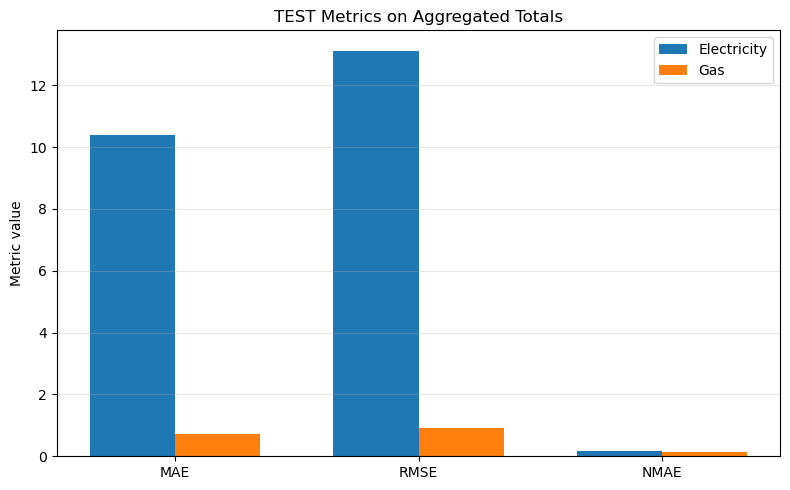

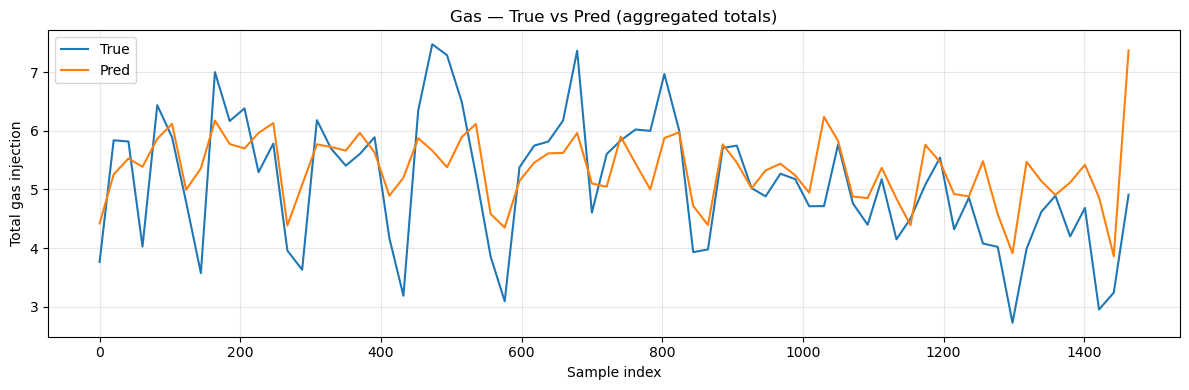

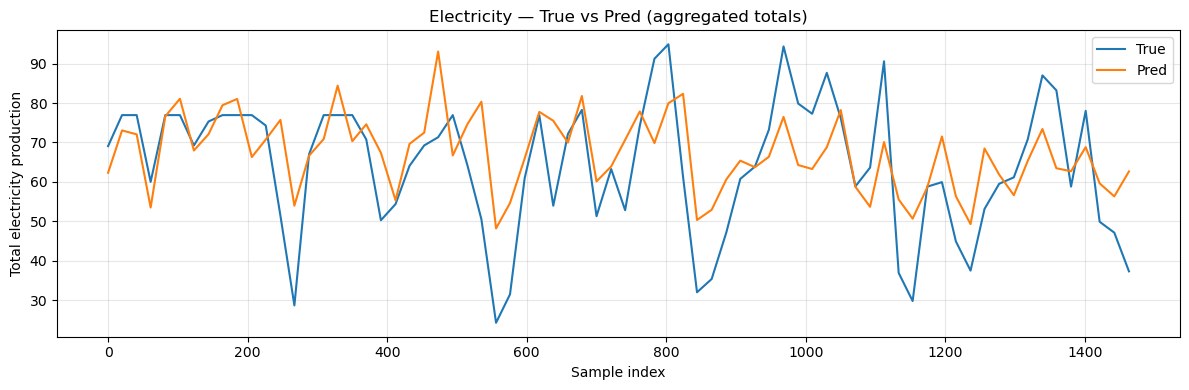

In [77]:
rows = []

m_elec = mae_rmse_nmae(elec_test_true_tot, elec_test_pred_tot)
m_elec["model"] = "CoupledModel_electricity_aggregated_total"
rows.append(m_elec)

m_gas = mae_rmse_nmae(gas_test_true_tot, gas_test_pred_tot)
m_gas["model"] = "CoupledModel_gas_aggregated_total"
rows.append(m_gas)

agg_total_df = pd.DataFrame(rows)[["model", "MAE", "RMSE", "NMAE"]]
print("=== TEST — Aggregated totals metrics ===")
display(agg_total_df)

# Plot metrics
metric_names = ["MAE", "RMSE", "NMAE"]
x = np.arange(len(metric_names))
w = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x - w/2, [m_elec[k] for k in metric_names], width=w, label="Electricity")
plt.bar(x + w/2, [m_gas[k] for k in metric_names], width=w, label="Gas")
plt.xticks(x, metric_names)
plt.ylabel("Metric value")
plt.title("TEST Metrics on Aggregated Totals")
plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Plot true vs pred aggregated totals
elec_true_1d = elec_test_true_tot.reshape(-1)
elec_pred_1d = elec_test_pred_tot.reshape(-1)

gas_true_1d = gas_test_true_tot.reshape(-1)
gas_pred_1d = gas_test_pred_tot.reshape(-1)

N_POINTS = 72

def downsample_pair(y_true, y_pred, n_points=300):
    n = min(len(y_true), len(y_pred))
    y_true = y_true[:n]
    y_pred = y_pred[:n]
    if n <= n_points:
        idx = np.arange(n)
    else:
        idx = np.linspace(0, n - 1, n_points).astype(int)
    return idx, y_true[idx], y_pred[idx]

idx_g, gas_true_plot, gas_pred_plot = downsample_pair(gas_true_1d, gas_pred_1d, N_POINTS)
idx_e, elec_true_plot, elec_pred_plot = downsample_pair(elec_true_1d, elec_pred_1d, N_POINTS)

plt.figure(figsize=(12, 4))
plt.plot(idx_g, gas_true_plot, label="True")
plt.plot(idx_g, gas_pred_plot, label="Pred")
plt.xlabel("Sample index")
plt.ylabel("Total gas injection")
plt.title("Gas — True vs Pred (aggregated totals)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(idx_e, elec_true_plot, label="True")
plt.plot(idx_e, elec_pred_plot, label="Pred")
plt.xlabel("Sample index")
plt.ylabel("Total electricity production")
plt.title("Electricity — True vs Pred (aggregated totals)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()